In [ ]:
from sklearn.datasets import make_blobs
from sklearn.neural_network import MLPClassifier, MLPRegressor
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import numpy as np

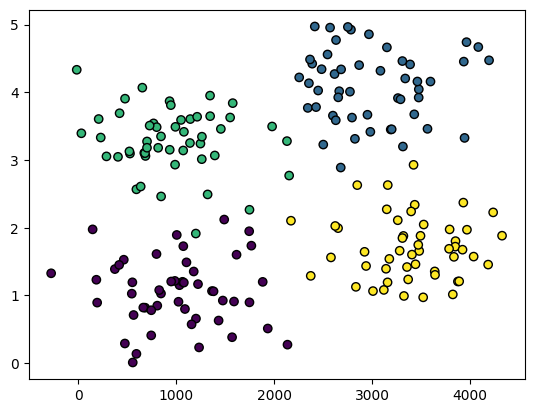

In [ ]:
blob_centers = ([1, 1], [3, 4], [1, 3.3], [3.5, 1.8])
X, y = make_blobs(n_samples=200,
                          centers=blob_centers,
                          cluster_std=0.5,
                          random_state=0)

X[:, 0] *= 1000

plt.scatter(X[:, 0], X[:, 1], c=y,  edgecolors='black',linewidth=1)

In [ ]:
y

array([0, 3, 0, 1, 1, 0, 0, 3, 3, 0, 2, 3, 2, 1, 2, 3, 0, 3, 1, 3, 2, 1,
       1, 2, 2, 1, 1, 1, 0, 0, 1, 1, 2, 1, 2, 3, 2, 3, 3, 0, 0, 1, 0, 2,
       2, 2, 3, 2, 0, 1, 2, 0, 2, 0, 2, 2, 3, 3, 0, 2, 2, 3, 2, 1, 3, 0,
       1, 2, 0, 3, 3, 2, 2, 3, 2, 0, 3, 1, 0, 0, 3, 1, 1, 3, 3, 3, 0, 1,
       1, 0, 3, 1, 2, 1, 0, 3, 0, 2, 0, 1, 0, 0, 1, 0, 3, 1, 3, 2, 0, 3,
       1, 3, 3, 3, 2, 3, 1, 0, 3, 2, 2, 1, 2, 3, 1, 1, 2, 0, 1, 1, 1, 0,
       1, 2, 3, 0, 2, 1, 0, 3, 1, 1, 1, 3, 2, 3, 0, 1, 1, 2, 1, 0, 2, 3,
       0, 0, 2, 3, 2, 1, 0, 1, 0, 2, 2, 3, 0, 3, 1, 1, 0, 2, 3, 2, 0, 3,
       1, 0, 1, 3, 3, 2, 1, 2, 1, 3, 2, 3, 2, 0, 0, 0, 0, 2, 3, 3, 0, 2,
       0, 2])

In [ ]:
clf = MLPClassifier(hidden_layer_sizes=(6,),
                    random_state=1).fit(X, y)

In [ ]:
print("Веса между входным и скрытым слоем:")
print(clf.coefs_[0])
print("\nВеса между скрытым и выходным слоем:")
print(clf.coefs_[1])

Веса между входным и скрытым слоем:
[[-0.09809877  0.33667051 -0.82024119 -0.29720839 -0.56852789 -0.66056109]
 [-0.58903611 -0.31219238 -0.22424296  0.11423652 -0.18324369  0.37321781]]

Веса между скрытым и выходным слоем:
[[-0.51316658 -0.43365467  0.43189995  0.68148414]
 [-0.24370005  0.34328608  0.57835494  0.57889271]
 [-0.59713359 -0.67678056 -0.46609801  0.54011704]
 [-0.5769702  -0.10221922  0.75476969  0.00610289]
 [ 0.34285864 -0.25645017  0.33417991  0.47281254]
 [-0.7006119   0.35515533  0.80295119  0.33880635]]


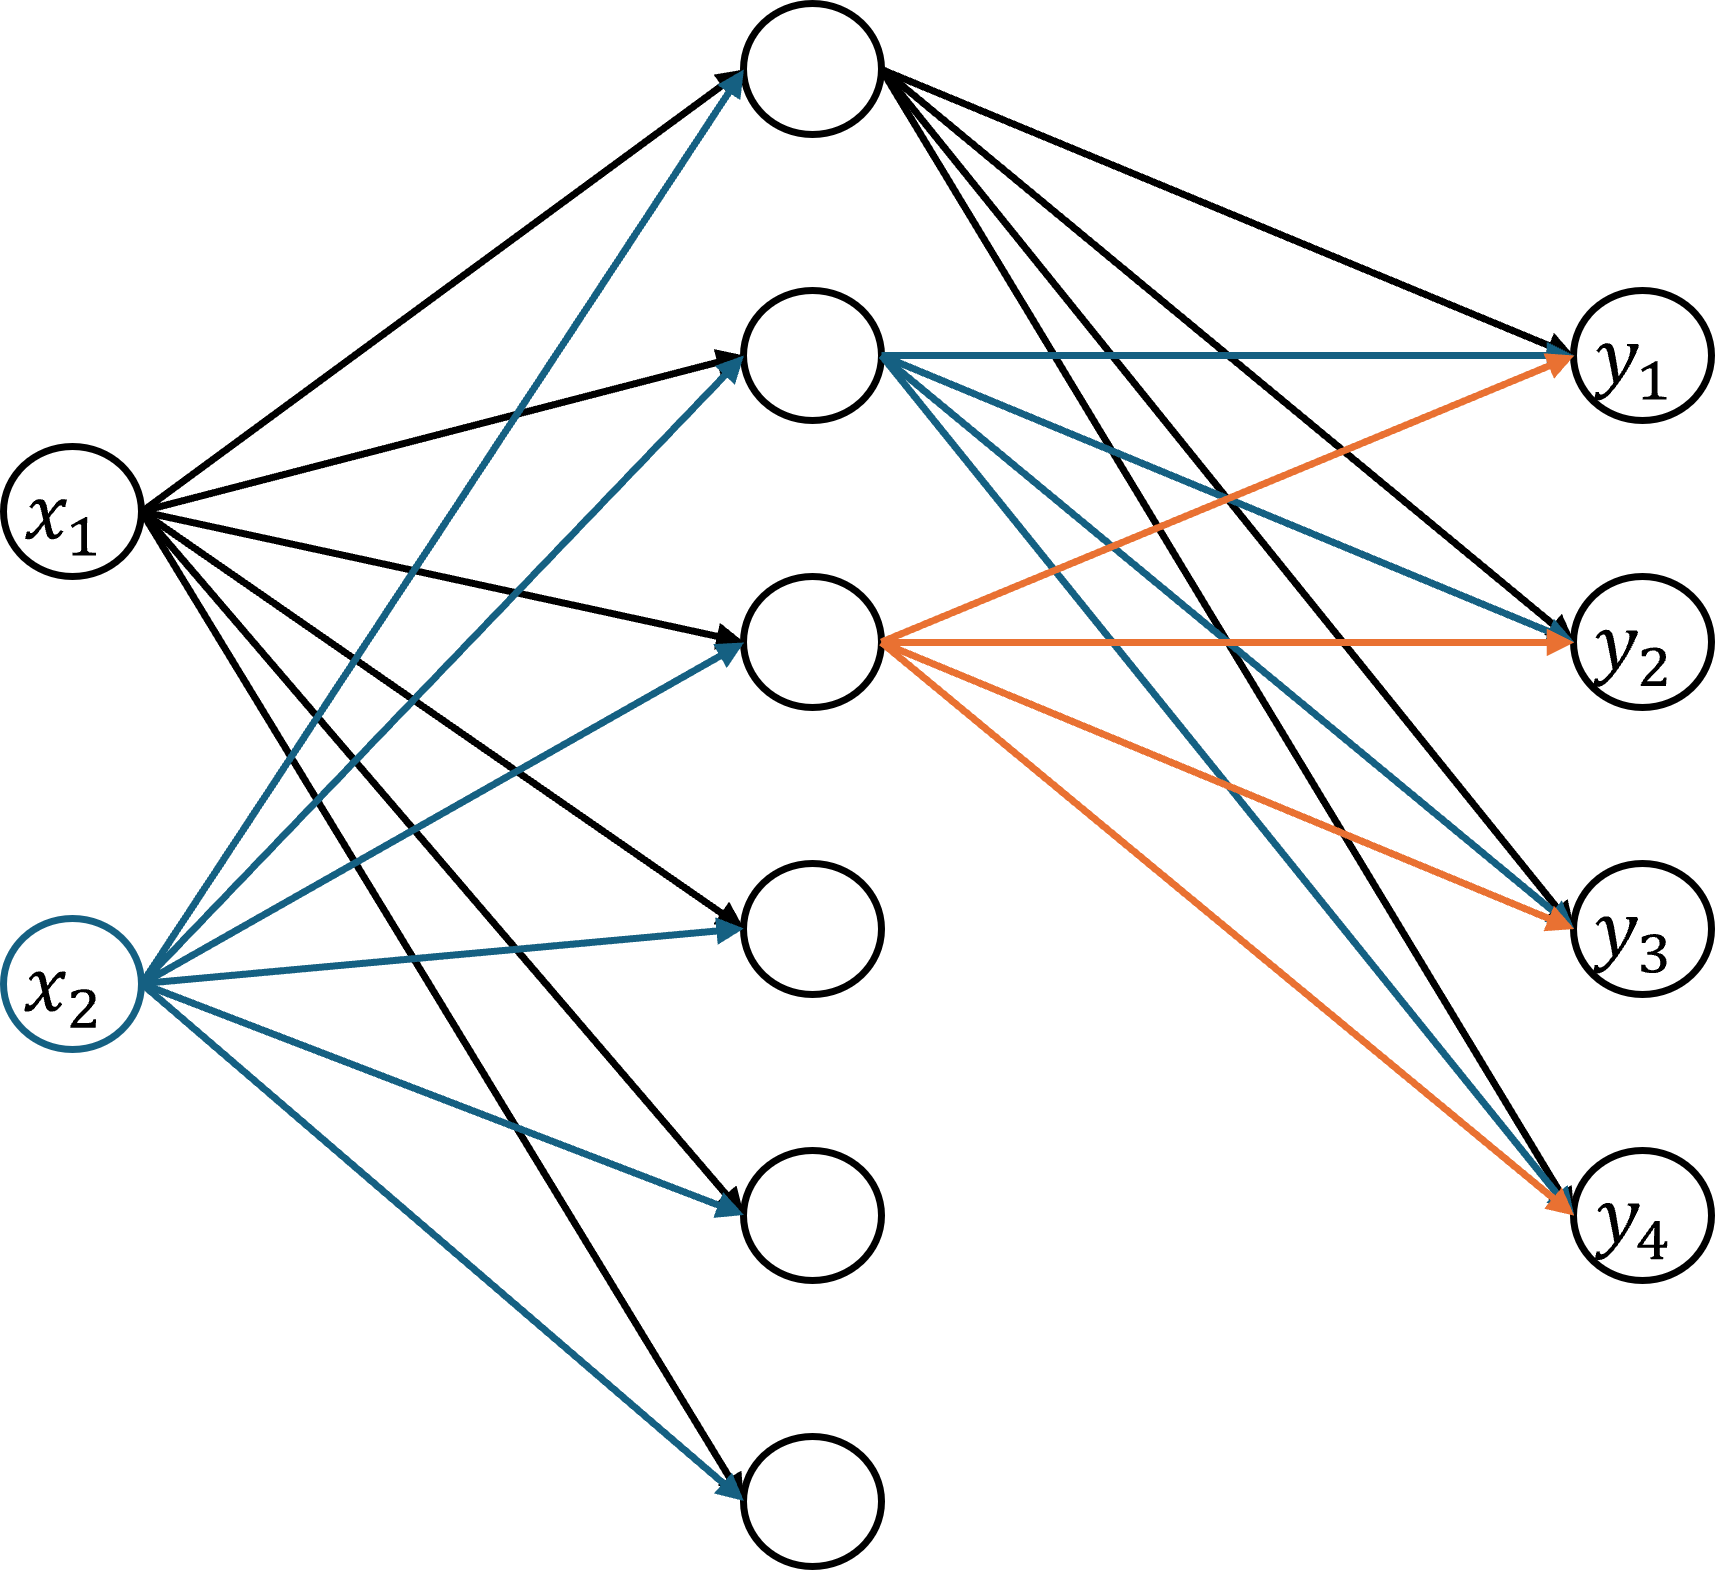

In [ ]:
print("Смещения для скрытого слоя:")
print(clf.intercepts_[0])
print("\nСмещения для выходного слоя:")
print(clf.intercepts_[1])

Смещения для скрытого слоя:
[-0.55752645  0.60978582 -0.8640854   0.33258994 -0.18652436  0.05696655]

Смещения для выходного слоя:
[-0.29413473  0.49414359 -0.60792984 -0.11888525]


In [ ]:
confusion_matrix(y, clf.predict(X))

array([[ 0,  0,  0, 50],
       [ 0,  0,  0, 50],
       [ 0,  0,  0, 50],
       [ 0,  0,  0, 50]])

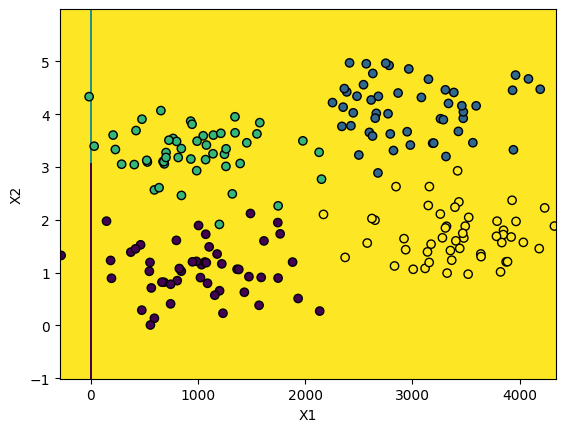

In [ ]:
X0 = np.linspace(X[:, 0].min()-1,X[:, 0].max()+1, X.shape[0])
X1 = np.linspace(X[:, 1].min()-1,X[:, 1].max()+1, X.shape[0])
X0_grid, X1_grid = np.meshgrid(X0, X1)

y_predict = clf.predict(np.c_[X0_grid.ravel(),X1_grid.ravel()]).reshape(X0_grid.shape)
plt.pcolormesh(X0_grid, X1_grid, y_predict)

plt.scatter(X[:, 0], X[:, 1], c=y,  edgecolors='black',linewidth=1)
plt.xlabel('X1')
plt.ylabel('X2')
plt.show()

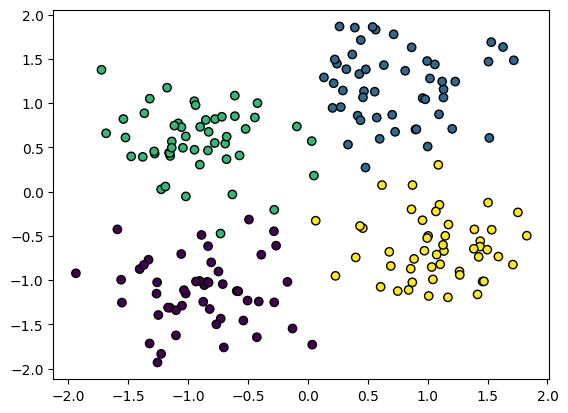

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y,  edgecolors='black',linewidth=1)

In [ ]:
clf = MLPClassifier(hidden_layer_sizes=(6,)).fit(X_scaled, y)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


In [ ]:
confusion_matrix(y, clf.predict(X_scaled))

array([[48,  0,  0,  2],
       [49,  0,  0,  1],
       [ 1,  0,  0, 49],
       [30,  0,  0, 20]])

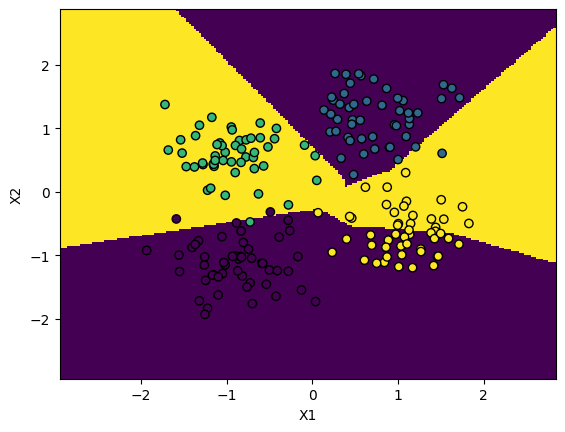

In [ ]:
X0 = np.linspace(X_scaled[:, 0].min()-1,X_scaled[:, 0].max()+1, X_scaled.shape[0])
X1 = np.linspace(X_scaled[:, 1].min()-1,X_scaled[:, 1].max()+1, X_scaled.shape[0])
X0_grid, X1_grid = np.meshgrid(X0, X1)

y_predict = clf.predict(np.c_[X0_grid.ravel(),X1_grid.ravel()]).reshape(X0_grid.shape)
plt.pcolormesh(X0_grid, X1_grid, y_predict)

plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y,  edgecolors='black',linewidth=1)
plt.xlabel('X1')
plt.ylabel('X2')
plt.show()

In [ ]:
clf = MLPClassifier(hidden_layer_sizes=(6,), max_iter=10000).fit(X_scaled, y)

In [ ]:
confusion_matrix(y, clf.predict(X_scaled))

array([[49,  0,  1,  0],
       [ 0, 50,  0,  0],
       [ 2,  1, 46,  1],
       [ 0,  1,  0, 49]])

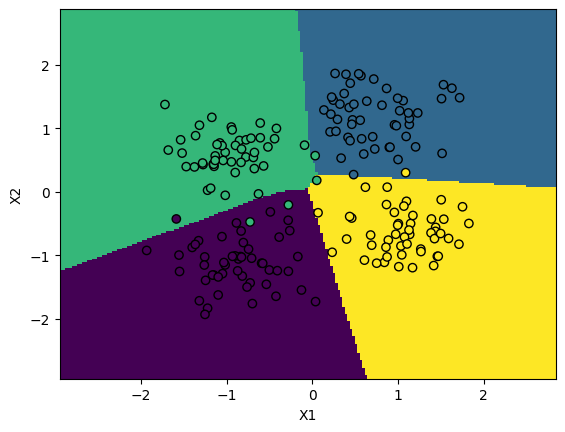

In [ ]:
X0 = np.linspace(X_scaled[:, 0].min()-1,X_scaled[:, 0].max()+1, X_scaled.shape[0])
X1 = np.linspace(X_scaled[:, 1].min()-1,X_scaled[:, 1].max()+1, X_scaled.shape[0])
X0_grid, X1_grid = np.meshgrid(X0, X1)

y_predict = clf.predict(np.c_[X0_grid.ravel(),X1_grid.ravel()]).reshape(X0_grid.shape)
plt.pcolormesh(X0_grid, X1_grid, y_predict)

plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y,  edgecolors='black',linewidth=1)
plt.xlabel('X1')
plt.ylabel('X2')
plt.show()

In [ ]:
clf = MLPClassifier(hidden_layer_sizes=(6, 6, 6), max_iter=10_000).fit(X_scaled, y)

In [ ]:
confusion_matrix(y, clf.predict(X_scaled))

array([[49,  0,  1,  0],
       [ 0, 49,  0,  1],
       [ 1,  0, 49,  0],
       [ 0,  1,  0, 49]])

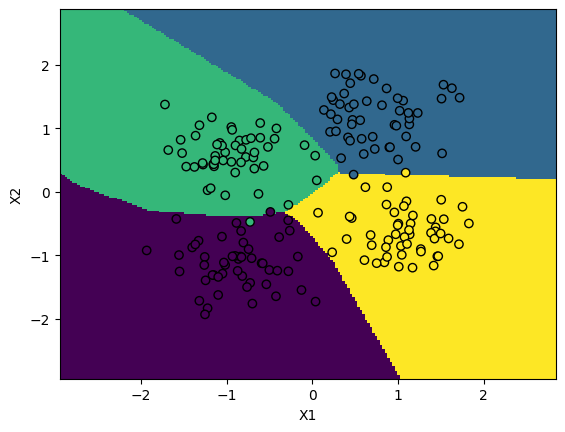

In [ ]:
X0 = np.linspace(X_scaled[:, 0].min()-1,X_scaled[:, 0].max()+1, X_scaled.shape[0])
X1 = np.linspace(X_scaled[:, 1].min()-1,X_scaled[:, 1].max()+1, X_scaled.shape[0])
X0_grid, X1_grid = np.meshgrid(X0, X1)

y_predict = clf.predict(np.c_[X0_grid.ravel(),X1_grid.ravel()]).reshape(X0_grid.shape)
plt.pcolormesh(X0_grid, X1_grid, y_predict)

plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y,  edgecolors='black',linewidth=1)
plt.xlabel('X1')
plt.ylabel('X2')
plt.show()

In [ ]:
clf.predict(X_scaled)

array([0, 3, 0, 1, 1, 0, 0, 3, 3, 0, 2, 3, 2, 1, 2, 3, 0, 3, 1, 3, 2, 1,
       1, 2, 2, 1, 1, 1, 0, 0, 1, 1, 2, 1, 2, 3, 2, 3, 3, 0, 0, 1, 0, 2,
       2, 2, 3, 2, 0, 1, 2, 0, 2, 0, 2, 2, 3, 3, 0, 2, 2, 3, 2, 1, 3, 0,
       1, 2, 0, 3, 3, 2, 2, 3, 0, 0, 3, 1, 0, 0, 3, 1, 1, 3, 3, 3, 0, 1,
       1, 0, 3, 1, 2, 1, 0, 3, 0, 2, 0, 1, 0, 0, 3, 0, 3, 1, 3, 2, 0, 3,
       1, 3, 3, 1, 2, 3, 1, 0, 3, 2, 2, 1, 2, 3, 1, 1, 2, 0, 1, 1, 1, 0,
       1, 2, 3, 0, 2, 1, 0, 3, 1, 1, 1, 3, 2, 3, 0, 1, 1, 2, 1, 0, 2, 3,
       0, 0, 2, 3, 2, 1, 0, 1, 0, 2, 2, 3, 0, 3, 1, 1, 0, 2, 3, 2, 0, 3,
       1, 0, 1, 3, 3, 2, 1, 2, 1, 3, 2, 3, 2, 0, 0, 2, 0, 2, 3, 3, 0, 2,
       0, 2])

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score
import time
from sklearn.datasets import load_iris, load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.datasets import fetch_openml

In [ ]:
blob_centers = ([1, 1], [3, 4], [1, 3.3], [3.5, 1.8])
X, y = make_blobs(n_samples=200,
                  centers=blob_centers,
                  cluster_std=0.5,
                  random_state=0)
X[:, 0] *= 1000

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

1. Создайте однослойный перцептрон с 1, 2, 10 и 100 нейронами. Сравние их точность и сделайте вывод о достаточном количестве нейронов.

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


Нейронов: 1, Точность: 0.3950


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


Нейронов: 2, Точность: 0.9750
Нейронов: 10, Точность: 0.9850
Нейронов: 100, Точность: 0.9950


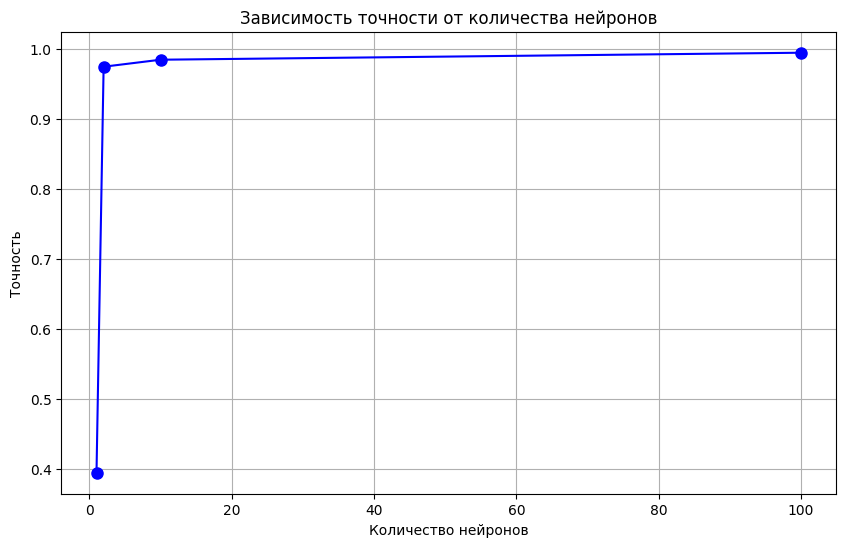

In [ ]:
neurons_list = [1, 2, 10, 100]
accuracies = []

for neurons in neurons_list:
    clf = MLPClassifier(hidden_layer_sizes=(neurons,),
                       max_iter=1000,
                       random_state=42)
    clf.fit(X_scaled, y)
    y_pred = clf.predict(X_scaled)
    accuracy = accuracy_score(y, y_pred)
    accuracies.append(accuracy)
    print(f"Нейронов: {neurons}, Точность: {accuracy:.4f}")

plt.figure(figsize=(10, 6))
plt.plot(neurons_list, accuracies, 'bo-', markersize=8)
plt.xlabel('Количество нейронов')
plt.ylabel('Точность')
plt.title('Зависимость точности от количества нейронов')
plt.grid(True)
plt.show()


2. Создайте и оцените модель с двумя, тремя и десятью скрытыми слоями с одинаковым количеством нейронов. Сравните их точность и сделайте вывод о достаточном количестве слоев.

In [ ]:
layer_configs = [
    (6, 6),
    (6, 6, 6),
    (6, 6, 6, 6, 6, 6, 6, 6, 6, 6)
]

layer_accuracies = []

for i, layers in enumerate(layer_configs):
    clf = MLPClassifier(hidden_layer_sizes=layers,
                       max_iter=2000,
                       random_state=42)
    clf.fit(X_scaled, y)
    y_pred = clf.predict(X_scaled)
    accuracy = accuracy_score(y, y_pred)
    layer_accuracies.append(accuracy)
    print(f"Конфигурация {i+1}: {layers}")
    print(f"Количество слоев: {len(layers)}, Точность: {accuracy:.4f}")
    print("-" * 50)

Конфигурация 1: (6, 6)
Количество слоев: 2, Точность: 0.9850
--------------------------------------------------
Конфигурация 2: (6, 6, 6)
Количество слоев: 3, Точность: 0.9850
--------------------------------------------------
Конфигурация 3: (6, 6, 6, 6, 6, 6, 6, 6, 6, 6)
Количество слоев: 10, Точность: 0.9950
--------------------------------------------------


3. Для глубокой модели выведите веса всех нейронов на всех слоях. Выведите значения векторов весов смещения.

In [ ]:
deep_model = MLPClassifier(hidden_layer_sizes=(6, 6, 6),
                          max_iter=2000,
                          random_state=42)
deep_model.fit(X_scaled, y)

print("Веса модели с тремя скрытыми слоями (6, 6, 6):")
for i in range(len(deep_model.coefs_)):
    print(f"\nСлой {i+1}:")
    print(f"Форма матрицы весов: {deep_model.coefs_[i].shape}")
    print(f"Первые 5 весов первого нейрона: {deep_model.coefs_[i][:5, 0]}")

print("\nВеса смещения:")
for i in range(len(deep_model.intercepts_)):
    print(f"Слой {i+1}: {deep_model.intercepts_[i]}")

Веса модели с тремя скрытыми слоями (6, 6, 6):

Слой 1:
Форма матрицы весов: (2, 6)
Первые 5 весов первого нейрона: [ 0.42089234 -1.35357039]

Слой 2:
Форма матрицы весов: (6, 6)
Первые 5 весов первого нейрона: [ 0.67542993 -0.55077381  0.11810507 -0.31558233 -1.50272282]

Слой 3:
Форма матрицы весов: (6, 6)
Первые 5 весов первого нейрона: [-1.28690122e-01 -3.49632510e-01 -1.03176427e-01 -3.95641782e-05
 -5.37881369e-04]

Слой 4:
Форма матрицы весов: (6, 4)
Первые 5 весов первого нейрона: [-0.0199166   0.01282258 -1.27050107 -0.3332662   0.54029114]

Веса смещения:
Слой 1: [ 1.22225487 -0.07820575 -0.63893321 -0.62498034 -0.25445048  0.52070882]
Слой 2: [ 0.71123764  1.31054565 -0.06207059 -0.04704309 -0.21141624  0.21047178]
Слой 3: [-0.00385396  0.54193383 -0.44506783 -0.29874884 -0.39943003  0.83907786]
Слой 4: [ 0.97330875  0.1584234  -0.80904272 -0.01660111]


4 .Постройте и оцените модель с большим количеством нейронов и слоев. Замерьте время выполнения обучения, сравните со временем обучения более простых моделей.

In [ ]:
complex_configs = [
    (10,),
    (50, 50),
    (100, 100, 100)
]

for config in complex_configs:
    start_time = time.time()
    clf = MLPClassifier(hidden_layer_sizes=config,
                       max_iter=1000,
                       random_state=42)
    clf.fit(X_scaled, y)
    end_time = time.time()

    y_pred = clf.predict(X_scaled)
    accuracy = accuracy_score(y, y_pred)

    print(f"Конфигурация: {config}")
    print(f"Время обучения: {end_time - start_time:.4f} сек")
    print(f"Точность: {accuracy:.4f}")
    print("-" * 50)

Конфигурация: (10,)
Время обучения: 0.7909 сек
Точность: 0.9850
--------------------------------------------------
Конфигурация: (50, 50)
Время обучения: 0.7076 сек
Точность: 0.9900
--------------------------------------------------
Конфигурация: (100, 100, 100)
Время обучения: 2.3811 сек
Точность: 0.9900
--------------------------------------------------


5. Постройте и оцените модель классификации с помощью перцептрона на датасете, который вы использовали на контрольной по классификиации (если вы ее не выполняли, возьмите любой датасет из раздела "real world datasets" в библиотеке sklearn).

In [ ]:
iris = load_iris()
X_iris, y_iris = iris.data, iris.target

X_iris_train, X_iris_test, y_iris_train, y_iris_test = train_test_split(
    X_iris, y_iris, test_size=0.3, random_state=42)

scaler_iris = StandardScaler()
X_iris_train_scaled = scaler_iris.fit_transform(X_iris_train)
X_iris_test_scaled = scaler_iris.transform(X_iris_test)

clf_iris = MLPClassifier(hidden_layer_sizes=(10, 10),
                        max_iter=2000,
                        random_state=42)
clf_iris.fit(X_iris_train_scaled, y_iris_train)

y_iris_pred = clf_iris.predict(X_iris_test_scaled)
accuracy_iris = accuracy_score(y_iris_test, y_iris_pred)

print(f"Точность на тестовой выборке (Iris): {accuracy_iris:.4f}")
print("Матрица ошибок:")
print(confusion_matrix(y_iris_test, y_iris_pred))

Точность на тестовой выборке (Iris): 1.0000
Матрица ошибок:
[[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]


6 .Постройте и оцените модель регрессии с помощью перцептрона на датасете, который вы использовали на контрольной по регрессии.

In [ ]:
np.random.seed(42)
n_samples = 500
n_features = 5

X = np.random.randn(n_samples, n_features)
y = 50 + 10*X[:,0] + 5*X[:,1] - 8*X[:,2] + 3*X[:,3] - 2*X[:,4] + np.random.randn(n_samples) * 5

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

regressor = MLPRegressor(
    hidden_layer_sizes=(50, 25),
    max_iter=1000,
    random_state=42
)
regressor.fit(X_train_scaled, y_train)

y_pred = regressor.predict(X_test_scaled)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse:.4f}")
print(f"R²: {r2:.4f}")

Задание 6: Регрессия с помощью перцептрона
MSE: 29.0828
R²: 0.8834


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
